# Week 6: Feature Engineering & Model Optimization
## House Price Prediction

### Objective

The objective of this project is to improve the performance of the house price prediction model developed in previous weeks through feature engineering, feature transformation, feature selection, and hyperparameter optimization.

The House Price Prediction dataset contains information about residential properties, including area, number of bedrooms, bathrooms, stories, parking spaces, location-related features, and furnishing status.

The dataset was initially cleaned during Week 1 by removing duplicate records and handling missing values. The cleaned dataset from Week 5 is used as the starting point for this week's analysis.

### Week 6 Goals

The following tasks will be performed:

1. Create meaningful features from existing variables.
2. Transform categorical and numerical variables into suitable formats for machine learning.
3. Identify and select the most relevant predictive features.
4. Establish a baseline model using the selected features.
5. Optimize the model using hyperparameter tuning and cross-validation.
6. Compare model performance before and after optimization.
7. Identify the most important predictors of house prices.
8. Document the findings and recommendations.

### Evaluation Metrics

Since this is a regression problem, model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, feature selection, model development, and hyperparameter optimization.

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel

import joblib

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [221]:
housing = pd.read_csv("./../data/cleaned/housing_cleaned.csv")

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [222]:
housing.shape

(545, 13)

In [223]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [224]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [225]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observation

The dataset contains the cleaned observations prepared during Week 1. The
verification confirms that missing values and duplicate records have already
been addressed.

The dataset contains both numerical and categorical variables. The numerical
variables describe characteristics such as price, area, number of bedrooms,
bathrooms, stories, and parking spaces, while categorical variables describe
features such as road access, guest rooms, basement availability,
air conditioning, preferred area, and furnishing status.

## 5. Identify Numerical and Categorical Features


In [226]:
housing.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [227]:
numerical_features = housing.select_dtypes(include=np.number).columns.tolist()
categorical_features = housing.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


# 6. Feature Engineering

Feature engineering involves creating new variables from existing data in
order to provide the machine learning model with more meaningful information.

The original dataset contains useful property characteristics, but some
relationships are not represented explicitly. For example, the number of
bedrooms alone does not describe the size of the property relative to the
number of bedrooms.

Therefore, additional features will be created to capture relationships
between existing variables.

The engineered features will be evaluated later to determine whether they
provide useful predictive information.

### 6.1 Total Rooms

The `bedrooms` and `bathrooms` variables provide separate information about the
layout of a house.

A new `total_rooms` feature combines these variables to provide a simple
measure of the number of major residential rooms represented in the dataset.

**Formula:**

`total_rooms = bedrooms + bathrooms`

In [228]:
housing["total_rooms"] = housing["bedrooms"] + housing["bathrooms"]

housing[["bedrooms", "bathrooms", "total_rooms"]].head()

,bedrooms,bathrooms,total_rooms
0,4,2,6
1,4,4,8
2,3,2,5
3,4,2,6
4,4,1,5


### 6.2 Area per Bedroom

The total area of a property is an important factor in determining its price.
However, the same area may represent different levels of spaciousness
depending on the number of bedrooms.

The `area_per_bedroom` feature measures the available area relative to the
number of bedrooms.

**Formula:**

`area_per_bedroom = area / bedrooms`

A small constant is used in the denominator to avoid division-by-zero errors.

In [229]:
housing["area_per_bedroom"] = (
    housing["area"] / housing["bedrooms"].replace(0, np.nan)
)

housing["area_per_bedroom"] = housing["area_per_bedroom"].fillna(0)

housing[["area", "bedrooms", "area_per_bedroom"]].head()

,area,bedrooms,area_per_bedroom
0,7420,4,1855.0
1,8960,4,2240.0
2,9960,3,3320.0
3,7500,4,1875.0
4,7420,4,1855.0


### 6.3 Bathrooms per Bedroom

The number of bathrooms can indicate the level of comfort and facilities
available in a property.

Rather than considering bathrooms independently, the
`bathrooms_per_bedroom` feature measures the number of bathrooms relative to
the number of bedrooms.

**Formula:**

`bathrooms_per_bedroom = bathrooms / bedrooms`

In [230]:
housing["bathrooms_per_bedroom"] = (
    housing["bathrooms"] / housing["bedrooms"].replace(0, np.nan)
)

housing["bathrooms_per_bedroom"] = housing["bathrooms_per_bedroom"].fillna(0)

housing[["bedrooms", "bathrooms", "bathrooms_per_bedroom"]].head()

,bedrooms,bathrooms,bathrooms_per_bedroom
0,4,2,0.500000
1,4,4,1.000000
2,3,2,0.666667
3,4,2,0.500000
4,4,1,0.250000


### 6.4 Total Amenities

Several variables in the dataset indicate the presence or absence of property
amenities:

- Guestroom
- Basement
- Hot water heating
- Air conditioning
- Main road access
- Preferred area

These variables are currently represented as separate categorical variables.
A new `total_amenities` feature aggregates selected property features to
represent the overall availability of these amenities.

Each available amenity is assigned a value of 1, while its absence is assigned
0.

This feature provides the model with a single measure of the property's
overall amenity availability.

In [231]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    housing[col + "_binary"] = housing[col].map({"yes": 1, "no": 0})

In [232]:
housing["total_amenities"] = housing[
    [col + "_binary" for col in binary_columns]
].sum(axis=1)

housing[["total_amenities"]].head()

,total_amenities
0,3
1,2
2,3
3,4
4,4


### 6.5 Property Size Category

The `area` variable is continuous. For additional analysis, properties can
also be grouped into size categories.

The categories are based on the distribution of property areas rather than
arbitrary thresholds. Quartiles are used to divide properties into four
groups:

- Small
- Medium
- Large
- Very Large

This provides a categorical representation of property size while preserving
the original continuous `area` variable for the machine learning models.

In [233]:
housing["area_category"] = pd.qcut(
    housing["area"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"]
)

housing[["area", "area_category"]].head()

,area,area_category
0,7420,Very Large
1,8960,Very Large
2,9960,Very Large
3,7500,Very Large
4,7420,Very Large


## 7. Review the Engineered Features

After creating the new features, the dataset is inspected to verify that the
features were created correctly and to compare the original variables with
their engineered counterparts.

In [234]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_bedroom,bathrooms_per_bedroom,mainroad_binary,guestroom_binary,basement_binary,hotwaterheating_binary,airconditioning_binary,prefarea_binary,total_amenities,area_category
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,6,1855.0,0.500000,1,0,0,0,1,1,3,Very Large
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,8,2240.0,1.000000,1,0,0,0,1,0,2,Very Large
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,5,3320.0,0.666667,1,0,1,0,0,1,3,Very Large
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,6,1875.0,0.500000,1,0,1,0,1,1,4,Very Large
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5,1855.0,0.250000,1,1,1,0,1,0,4,Very Large


In [235]:
housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'total_rooms',
       'area_per_bedroom', 'bathrooms_per_bedroom', 'mainroad_binary',
       'guestroom_binary', 'basement_binary', 'hotwaterheating_binary',
       'airconditioning_binary', 'prefarea_binary', 'total_amenities',
       'area_category'],
      dtype='str')

In [236]:
housing.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_bedroom,bathrooms_per_bedroom,mainroad_binary,guestroom_binary,basement_binary,hotwaterheating_binary,airconditioning_binary,prefarea_binary,total_amenities,area_category
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Small
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,144
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN,4.251376,1819.852599,0.446361,0.858716,0.177982,0.350459,0.045872,0.315596,0.234862,1.983486,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN,1.036611,839.091825,0.159492,0.348635,0.382849,0.477552,0.209399,0.465180,0.424302,1.195004,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.000000,381.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.000000,1237.500000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.000000,1666.666667,0.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,5.000000,2183.333333,0.500000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,NaN


# 8. Feature Relationship Analysis

Before selecting features for modeling, it is useful to examine the
relationships between numerical variables.

Correlation analysis provides an initial indication of how strongly numerical
features are associated with house price.

A correlation close to +1 indicates a strong positive linear relationship,
while a correlation close to -1 indicates a strong negative relationship.
Values close to 0 indicate a weak linear relationship.

Correlation does not imply causation, but it provides useful evidence for
initial feature selection.

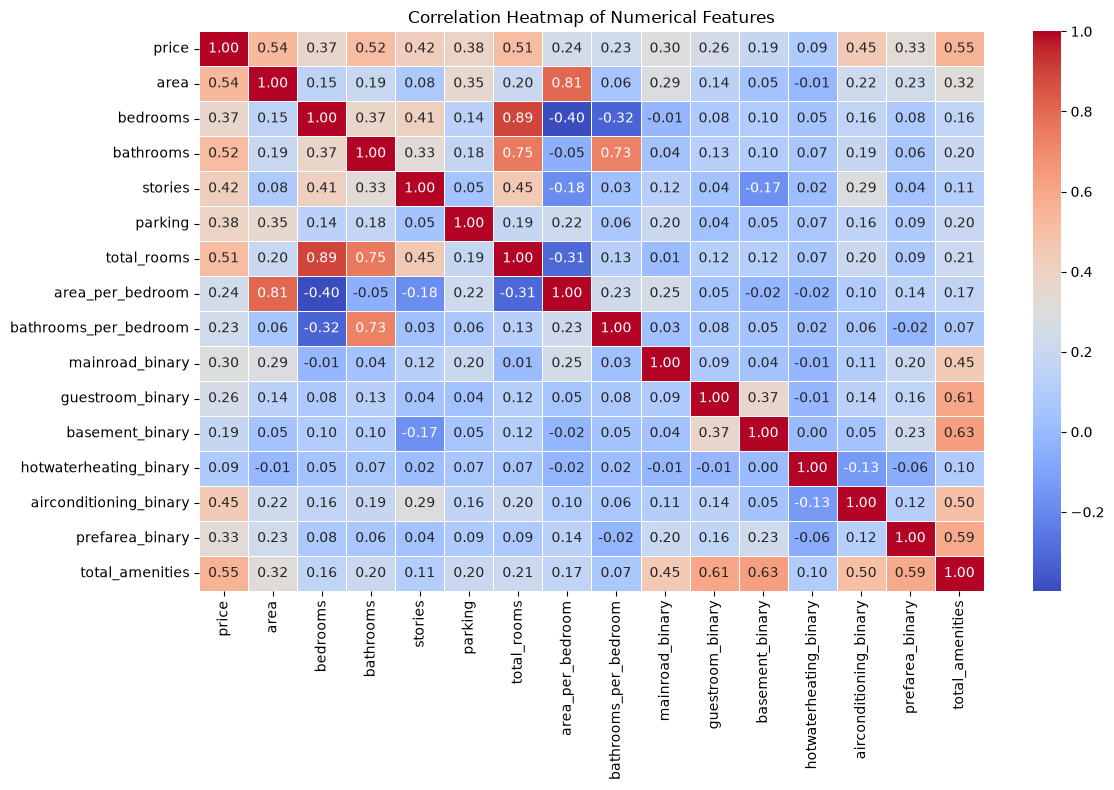

In [237]:
plt.figure(figsize=(12, 8))

numeric_data = housing.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [238]:
price_correlation = (
    correlation_matrix["price"]
    .sort_values(ascending=False)
)

price_correlation

price                     1.000000
total_amenities           0.552954
area                      0.535997
bathrooms                 0.517545
total_rooms               0.511809
airconditioning_binary    0.452954
stories                   0.420712
parking                   0.384394
bedrooms                  0.366494
prefarea_binary           0.329777
mainroad_binary           0.296898
guestroom_binary          0.255517
area_per_bedroom          0.244809
bathrooms_per_bedroom     0.231732
basement_binary           0.187057
hotwaterheating_binary    0.093073
Name: price, dtype: float64

# 9. Data Preparation for Modeling

The target variable is `price`, while all remaining variables are considered
potential predictors.

The dataset contains both numerical and categorical variables. Numerical
variables will be standardized using `StandardScaler`, while categorical
variables will be converted into numerical representations using
one-hot encoding.

A `ColumnTransformer` will be used to apply the appropriate transformation
to each feature type.

Using a preprocessing pipeline is important because the transformations are
learned only from the training data, helping prevent data leakage.

In [239]:
X = housing.drop("price", axis=1)
y = housing["price"]

In [240]:
binary_helper_columns = [col + "_binary" for col in binary_columns]

X = X.drop(columns=binary_helper_columns)

In [241]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'total_rooms', 'area_per_bedroom', 'bathrooms_per_bedroom', 'total_amenities']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## 10. Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to learn patterns and optimize the model, while the
testing set is kept separate and is used only for final performance
evaluation.

A test size of 20% is used, leaving 80% of the observations for training.

`random_state=42` is used to ensure that the same observations are selected
each time the notebook is executed.

In [242]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (436, 17)
Testing set: (109, 17)


# 11. Feature Transformation

The predictors contain both numerical and categorical variables, so different
transformations are required.

### Numerical features

Numerical variables are standardized using `StandardScaler`. Standardization
transforms the variables so that they have approximately zero mean and unit
variance.

### Categorical features

Categorical variables are transformed using `OneHotEncoder`. This creates
binary indicator variables for the different categories without introducing
an artificial numerical ordering.

The transformations are combined using `ColumnTransformer`.

In [243]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ]
)

# 12. Baseline Gradient Boosting Model

In Week 5, several regression algorithms were evaluated. Gradient Boosting
achieved the strongest performance among the tested models, with:

- MAE: **961,734.63**
- R²: **0.6650**

Therefore, Gradient Boosting Regressor is selected as the primary model for
Week 6 optimization.

The baseline model will first be trained using the engineered and transformed
features with default model hyperparameters. Its performance will then be
compared against the optimized model.

In [244]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['area','bedrooms','bathrooms',...,'bathrooms_per_bedroom', 'total_amenities','area_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [245]:
y_pred_baseline = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Gradient Boosting Performance")
print("-" * 45)
print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Gradient Boosting Performance
---------------------------------------------
MAE:  1,021,294.42
RMSE: 1,448,480.60
R²:   0.5849


# 14. Cross-Validation

A single train-test split provides only one estimate of model performance.
Cross-validation provides a more robust estimate by repeatedly training and
evaluating the model on different subsets of the training data.

Five-fold cross-validation is used in this project.

The training data is divided into five folds. The model is trained on four
folds and validated on the remaining fold. This process is repeated until
each fold has been used as the validation set.

The resulting scores provide an indication of how consistently the model
performs across different subsets of the data.

In [246]:
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print(f"\nMean CV R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation R² Scores:
[0.55827364 0.59082671 0.62242551 0.58931583 0.52695454]

Mean CV R²: 0.5776
Standard Deviation: 0.0324


### Cross-Validation Performance

The five-fold cross-validation scores are visualized to examine how
consistently the baseline Gradient Boosting model performs across the
different validation folds.

A smaller variation between folds indicates more consistent model
performance, while a larger variation may indicate that the model is
sensitive to the particular training and validation samples.

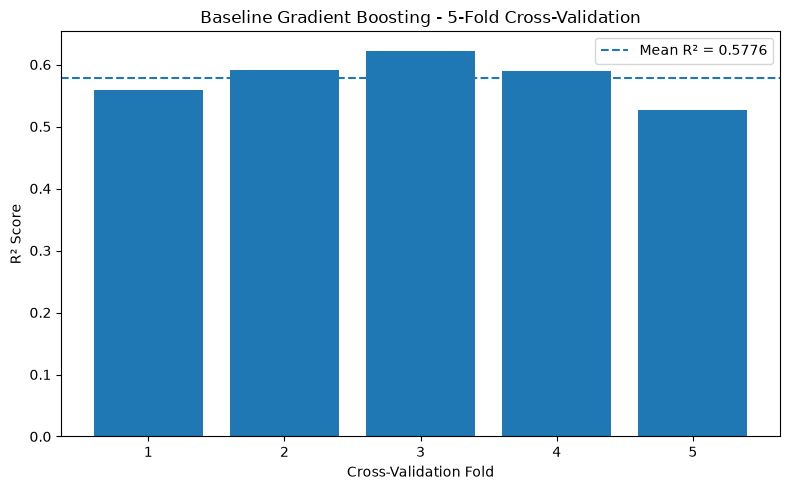

In [247]:
plt.figure(figsize=(8, 5))

fold_numbers = range(1, 6)

plt.bar(fold_numbers, cv_scores)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean R² = {cv_scores.mean():.4f}"
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")
plt.title("Baseline Gradient Boosting - 5-Fold Cross-Validation")
plt.xticks(fold_numbers)
plt.legend()
plt.tight_layout()
plt.show()

In [248]:
baseline_model.fit(X_train, y_train)

feature_names = (
    numerical_features +
    list(
        baseline_model
        .named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

feature_importances = (
    baseline_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
0,area,0.425753
5,total_rooms,0.130933
8,total_amenities,0.105471
2,bathrooms,0.078682
4,parking,0.047296
3,stories,0.042500
6,area_per_bedroom,0.035622
17,airconditioning_no,0.033254
23,furnishingstatus_unfurnished,0.022468
18,airconditioning_yes,0.019338


## 16. Feature Importance

Feature importance measures how much each feature contributes to the
predictions made by the Gradient Boosting model.

The most important features provide evidence about which characteristics of
a house have the greatest influence on predicted prices.

Because categorical variables were one-hot encoded, some original categorical
variables may appear as multiple encoded features in the importance results.

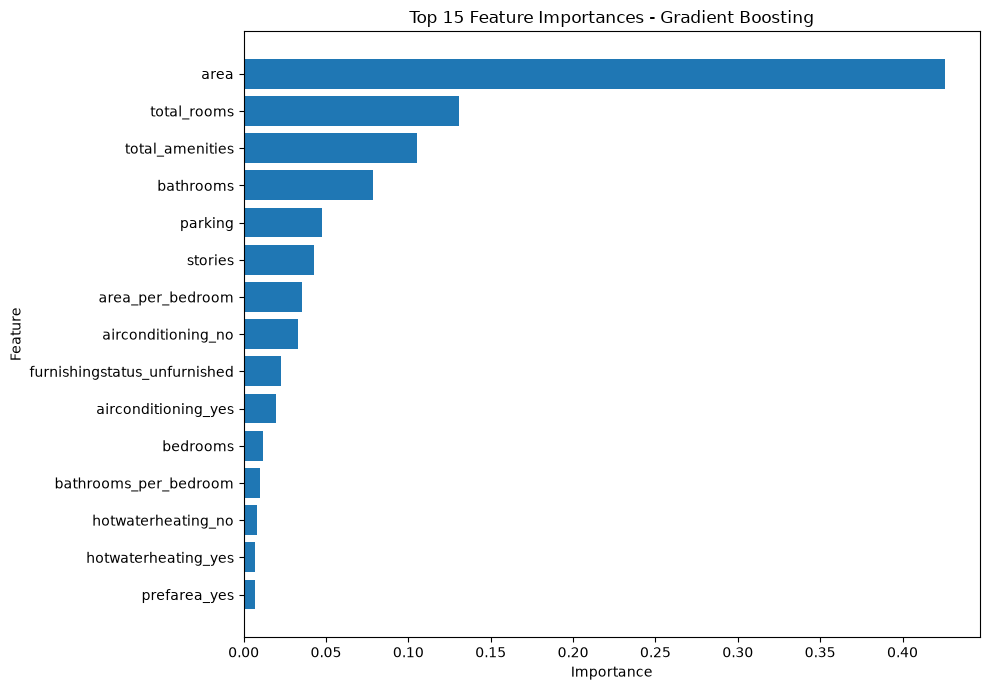

In [249]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()
plt.show()

In [250]:
feature_importance_df.head(15)

,Feature,Importance
0,area,0.425753
5,total_rooms,0.130933
8,total_amenities,0.105471
2,bathrooms,0.078682
4,parking,0.047296
3,stories,0.042500
6,area_per_bedroom,0.035622
17,airconditioning_no,0.033254
23,furnishingstatus_unfurnished,0.022468
18,airconditioning_yes,0.019338


# 17. Feature Selection

Feature selection aims to retain the most informative predictors while
reducing the influence of features that contribute relatively little to the
model.

For this project, tree-based feature importance is used because Gradient
Boosting can capture nonlinear relationships between predictors and house
prices.

The feature importance results showed that `area` was the dominant predictor,
followed by `total_rooms`, `total_amenities`, `bathrooms`, `parking`,
`stories`, and `area_per_bedroom`.

Rather than manually removing features based only on their individual
importance values, `SelectFromModel` is used to perform feature selection
within the machine learning pipeline.

A median importance threshold is used. Features with importance above the
median are retained.

Keeping feature selection inside the pipeline ensures that the selection
process is performed using only the training portion of each cross-validation
fold, reducing the risk of data leakage.

In [251]:
feature_selector = SelectFromModel(
    estimator=GradientBoostingRegressor(random_state=42),
    threshold="median"
)

In [252]:
feature_selection_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", feature_selector),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

### Feature Selection Findings

The feature selection process reduced the transformed feature space from
24 features to 12 features.

The retained features were:

- `area`
- `bedrooms`
- `bathrooms`
- `stories`
- `parking`
- `total_rooms`
- `area_per_bedroom`
- `bathrooms_per_bedroom`
- `total_amenities`
- `airconditioning_no`
- `airconditioning_yes`
- `furnishingstatus_unfurnished`

The selection process retained the major structural characteristics of the
properties, particularly `area`, `total_rooms`, `bathrooms`, `parking`, and
the engineered features.

Feature selection improved the test-set R² from 0.5849 to 0.6037 and reduced
MAE from approximately 1.02 million to approximately 989,665.

The mean five-fold cross-validation R² also increased from 0.5776 to 0.5910,
while the standard deviation decreased from 0.0324 to 0.0223.

These results indicate that removing less informative transformed features
improved both predictive performance and consistency across validation folds.

# 18. Feature-Selected Baseline Model

The feature-selected Gradient Boosting model is evaluated using the same
train-test split used for the original baseline.

This provides a fair comparison between:

1. The baseline model using all engineered features.
2. The feature-selected model using only the features retained by the
   tree-based selection process.

This comparison helps determine whether removing less informative features
improves generalization or whether the additional features provide useful
information to the model.

In [253]:
feature_selection_model.fit(X_train, y_train)

y_pred_selected = feature_selection_model.predict(X_test)

selected_mae = mean_absolute_error(y_test, y_pred_selected)
selected_rmse = np.sqrt(mean_squared_error(y_test, y_pred_selected))
selected_r2 = r2_score(y_test, y_pred_selected)

print("Feature-Selected Gradient Boosting Performance")
print("-" * 55)
print(f"MAE:  {selected_mae:,.2f}")
print(f"RMSE: {selected_rmse:,.2f}")
print(f"R²:   {selected_r2:.4f}")

Feature-Selected Gradient Boosting Performance
-------------------------------------------------------
MAE:  989,665.31
RMSE: 1,415,363.52
R²:   0.6037


In [254]:
selected_cv_scores = cross_val_score(
    feature_selection_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Feature-Selected Cross-Validation R² Scores:")
print(selected_cv_scores)

print(f"\nMean CV R²: {selected_cv_scores.mean():.4f}")
print(f"Standard Deviation: {selected_cv_scores.std():.4f}")

Feature-Selected Cross-Validation R² Scores:
[0.57095849 0.62763878 0.60626478 0.57705025 0.57331548]

Mean CV R²: 0.5910
Standard Deviation: 0.0223


# 19. Selected Features

The feature selector operates after numerical scaling and categorical
one-hot encoding. Therefore, the selected feature names are obtained from
the fitted preprocessing stage.

This allows us to document exactly which transformed predictors were retained
for the optimized model.

In [255]:
preprocessor_fitted = (
    feature_selection_model
    .named_steps["preprocessor"]
)

selector_fitted = (
    feature_selection_model
    .named_steps["feature_selection"]
)

transformed_feature_names = (
    numerical_features +
    list(
        preprocessor_fitted
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

selected_mask = selector_fitted.get_support()

selected_features = [
    feature
    for feature, selected in zip(
        transformed_feature_names,
        selected_mask
    )
    if selected
]

print("Selected Features:")
for feature in selected_features:
    print("-", feature)

print(f"\nNumber of transformed features: {len(transformed_feature_names)}")
print(f"Number of selected features: {len(selected_features)}")

Selected Features:
- area
- bedrooms
- bathrooms
- stories
- parking
- total_rooms
- area_per_bedroom
- bathrooms_per_bedroom
- total_amenities
- airconditioning_no
- airconditioning_yes
- furnishingstatus_unfurnished

Number of transformed features: 24
Number of selected features: 12


# 20. Baseline vs Feature-Selected Model

The performance of the original baseline model and the feature-selected
model is compared using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate better performance.

For R², higher values indicate that the model explains a greater proportion
of the variation in house prices.

In [256]:
feature_selection_mae_improvement = (
    (baseline_mae - selected_mae) / baseline_mae
) * 100

feature_selection_rmse_improvement = (
    (baseline_rmse - selected_rmse) / baseline_rmse
) * 100

feature_selection_r2_improvement = (
    (selected_r2 - baseline_r2) / baseline_r2
) * 100

print(f"MAE improvement:  {feature_selection_mae_improvement:.2f}%")
print(f"RMSE improvement: {feature_selection_rmse_improvement:.2f}%")
print(f"R² improvement:   {feature_selection_r2_improvement:.2f}%")

MAE improvement:  3.10%
RMSE improvement: 2.29%
R² improvement:   3.21%


In [257]:
comparison_before_tuning = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Feature-Selected Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        selected_mae
    ],
    "RMSE": [
        baseline_rmse,
        selected_rmse
    ],
    "R²": [
        baseline_r2,
        selected_r2
    ]
})

comparison_before_tuning

,Model,MAE,RMSE,R²
0,Baseline Gradient Boosting,1.021294e+06,1.448481e+06,0.584911
1,Feature-Selected Gradient Boosting,9.896653e+05,1.415364e+06,0.603675


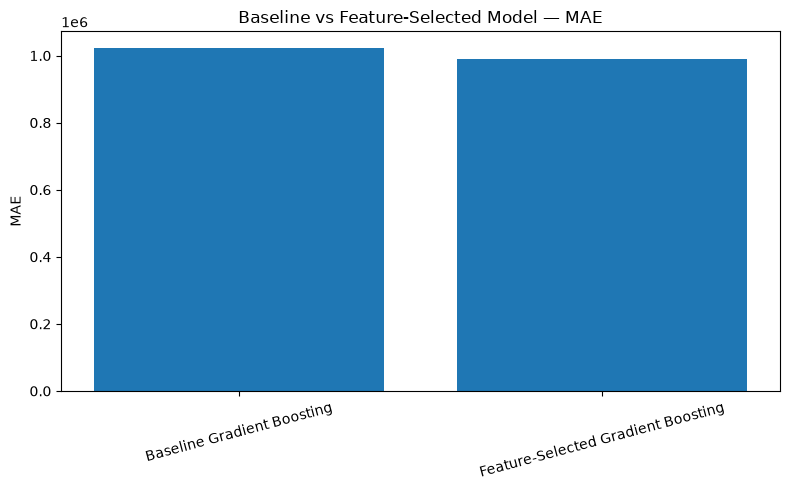

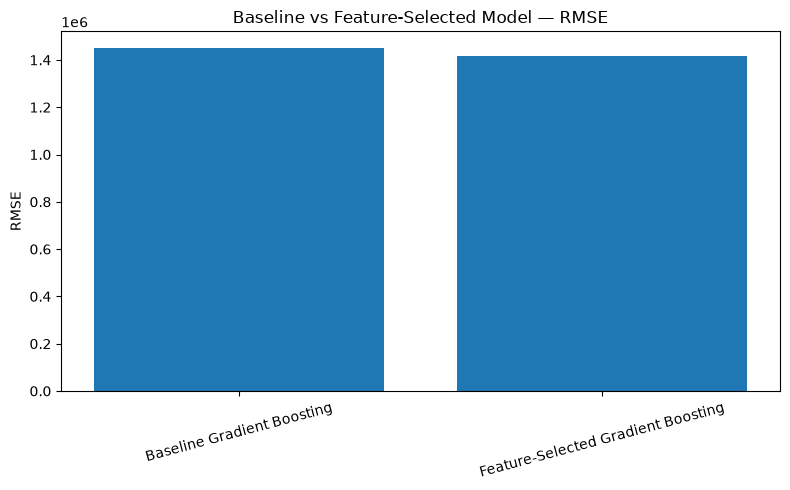

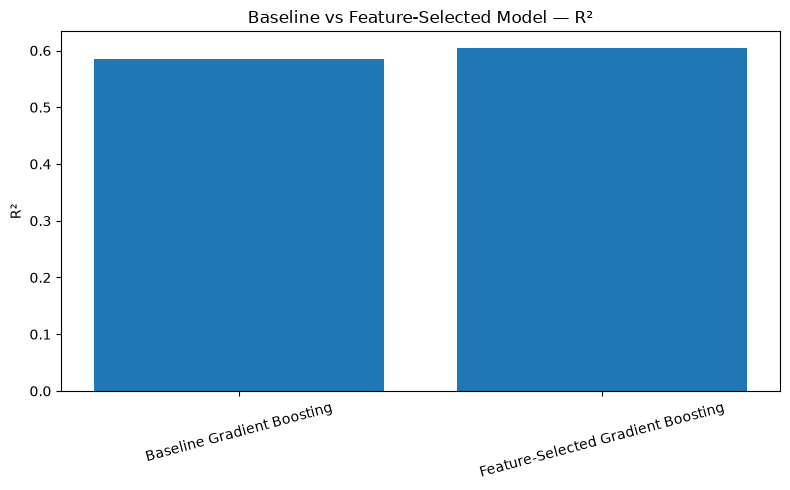

In [258]:
metrics = ["MAE", "RMSE", "R²"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison_before_tuning["Model"],
        comparison_before_tuning[metric]
    )

    plt.title(f"Baseline vs Feature-Selected Model — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# 21. Hyperparameter Optimization

Hyperparameter tuning is used to identify a better configuration of the
Gradient Boosting algorithm.

The baseline model uses the algorithm's default hyperparameters. These
defaults are not necessarily optimal for the House Price dataset.

Grid Search with five-fold cross-validation will be used to systematically
evaluate different combinations of hyperparameters.

### Parameters to be tested

- `n_estimators` — number of boosting stages.
- `learning_rate` — contribution of each individual tree.
- `max_depth` — maximum depth of the individual regression trees.
- `min_samples_split` — minimum number of samples required to split a node.
- `min_samples_leaf` — minimum number of samples required in a leaf.

The search is performed within the complete preprocessing and feature
selection pipeline. This ensures that preprocessing and feature selection
are performed correctly during cross-validation.

In [259]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# 22. Grid Search with Cross-Validation

`GridSearchCV` evaluates every combination of hyperparameters specified in
the parameter grid.

Five-fold cross-validation is used to estimate the performance of each
configuration.

The model is evaluated using the R² metric because R² is one of the primary
evaluation metrics for this regression problem.

The configuration with the highest mean cross-validation R² score will be
selected as the best model.

In [260]:
grid_search = GridSearchCV(
    estimator=feature_selection_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricev

# 23. Best Hyperparameters

After evaluating all parameter combinations, Grid Search identifies the
configuration that achieved the highest mean cross-validation R² score.

These parameters will be used to construct the final optimized Gradient
Boosting model.

In [261]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [262]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [263]:
print(f"Best Cross-Validation R²: {grid_search.best_score_:.4f}")

Best Cross-Validation R²: 0.6285


In [264]:
grid_results = pd.DataFrame(grid_search.cv_results_)

top_grid_results = (
    grid_results[
        [
            "mean_test_score",
            "std_test_score",
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__max_depth",
            "param_model__min_samples_split",
            "param_model__min_samples_leaf"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

top_grid_results

,mean_test_score,std_test_score,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf
129,0.628488,0.027485,100,0.05,3,5,4
126,0.628488,0.027485,100,0.05,3,2,4
132,0.627948,0.025852,100,0.05,3,10,4
153,0.627925,0.053770,100,0.05,4,2,4
156,0.627925,0.053770,100,0.05,4,5,4
90,0.627544,0.024070,100,0.05,2,2,2
96,0.626751,0.025433,100,0.05,2,10,2
93,0.626612,0.025297,100,0.05,2,5,2
84,0.626228,0.024595,100,0.05,2,5,1
74,0.625923,0.046409,300,0.01,4,2,4


# 24. Optimized Model Evaluation

The best estimator identified through Grid Search is evaluated against the
held-out test set.

The test set was not used to select the hyperparameters, allowing it to
provide an independent estimate of the optimized model's generalization
performance.

The optimized model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [265]:
optimized_model = grid_search.best_estimator_

y_pred_optimized = optimized_model.predict(X_test)

optimized_mae = mean_absolute_error(
    y_test,
    y_pred_optimized
)

optimized_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_optimized
    )
)

optimized_r2 = r2_score(
    y_test,
    y_pred_optimized
)

print("Optimized Gradient Boosting Performance")
print("-" * 50)
print(f"MAE:  {optimized_mae:,.2f}")
print(f"RMSE: {optimized_rmse:,.2f}")
print(f"R²:   {optimized_r2:.4f}")

Optimized Gradient Boosting Performance
--------------------------------------------------
MAE:  990,544.27
RMSE: 1,385,340.94
R²:   0.6203


In [266]:
optimization_mae_improvement = (
    (selected_mae - optimized_mae) / selected_mae
) * 100

optimization_rmse_improvement = (
    (selected_rmse - optimized_rmse) / selected_rmse
) * 100

optimization_r2_improvement = (
    (optimized_r2 - selected_r2) / selected_r2
) * 100

print(f"MAE improvement after tuning:  {optimization_mae_improvement:.2f}%")
print(f"RMSE improvement after tuning: {optimization_rmse_improvement:.2f}%")
print(f"R² improvement after tuning:   {optimization_r2_improvement:.2f}%")

MAE improvement after tuning:  -0.09%
RMSE improvement after tuning: 2.12%
R² improvement after tuning:   2.76%


# 25. Before vs After Optimization

The baseline and optimized models are compared to determine whether
hyperparameter tuning improved predictive performance.

The baseline represents the Gradient Boosting model before hyperparameter
optimization, while the optimized model uses the best configuration
identified through Grid Search and five-fold cross-validation.

For this regression problem:

- Lower MAE indicates smaller average prediction errors.
- Lower RMSE indicates smaller prediction errors while placing greater
  emphasis on large errors.
- Higher R² indicates that the model explains more variation in house prices.

In [267]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Optimized Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        optimized_mae
    ],
    "RMSE": [
        baseline_rmse,
        optimized_rmse
    ],
    "R²": [
        baseline_r2,
        optimized_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R²
0,Baseline Gradient Boosting,1.021294e+06,1.448481e+06,0.584911
1,Optimized Gradient Boosting,9.905443e+05,1.385341e+06,0.620310


In [268]:
mae_improvement = (
    (baseline_mae - optimized_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - optimized_rmse)
    / baseline_rmse
) * 100

r2_improvement = (
    (optimized_r2 - baseline_r2)
    / baseline_r2
) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"R² improvement:   {r2_improvement:.2f}%")

MAE improvement:  3.01%
RMSE improvement: 4.36%
R² improvement:   6.05%


# 27. Model Performance Comparison

The final performance comparison provides a visual summary of the effect of
model optimization.

The baseline and optimized models are compared across MAE, RMSE, and R².
This makes it easier to identify whether hyperparameter tuning produced a
meaningful improvement in predictive performance.

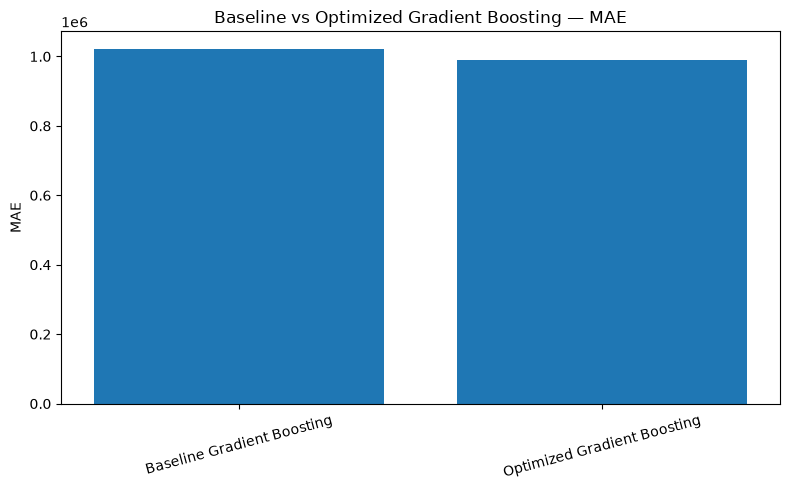

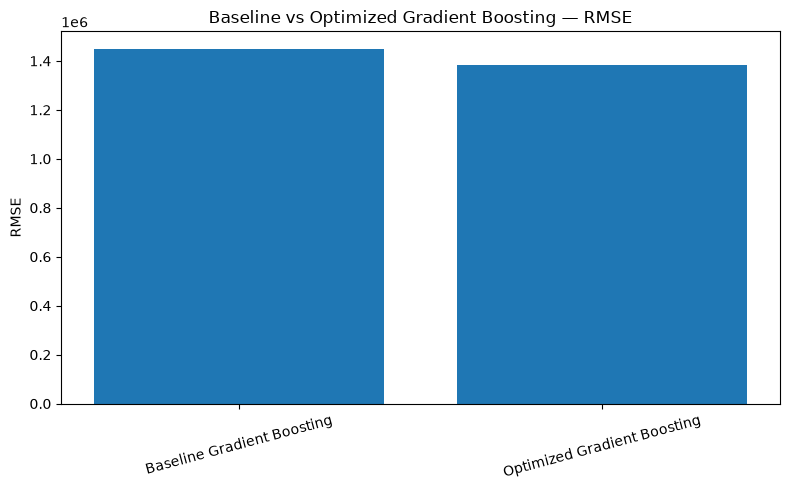

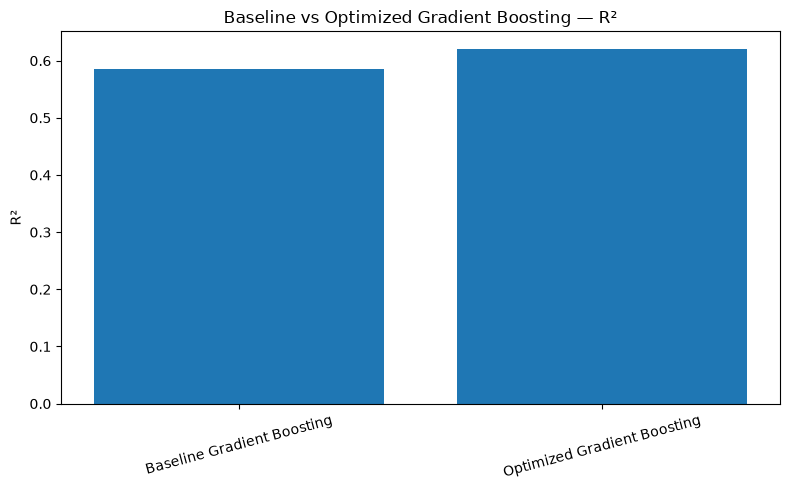

In [269]:
for metric in ["MAE", "RMSE", "R²"]:
    plt.figure(figsize=(8, 5))

    plt.bar(
        final_comparison["Model"],
        final_comparison[metric]
    )

    plt.title(f"Baseline vs Optimized Gradient Boosting — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# 28. Cross-Validation Comparison

The final evaluation also compares the cross-validation performance of the
baseline and optimized models.

Cross-validation provides evidence about model robustness across different
training and validation subsets.

An improvement in both the cross-validation score and held-out test
performance provides stronger evidence that the optimization improved
generalization rather than simply improving performance on one particular
train-test split.

In [270]:
optimized_cv_scores = cross_val_score(
    optimized_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Optimized Cross-Validation R² Scores:")
print(optimized_cv_scores)

print(f"\nMean Optimized CV R²: {optimized_cv_scores.mean():.4f}")
print(f"Standard Deviation: {optimized_cv_scores.std():.4f}")

Optimized Cross-Validation R² Scores:
[0.65481426 0.6601257  0.63198728 0.60730231 0.58821198]

Mean Optimized CV R²: 0.6285
Standard Deviation: 0.0275


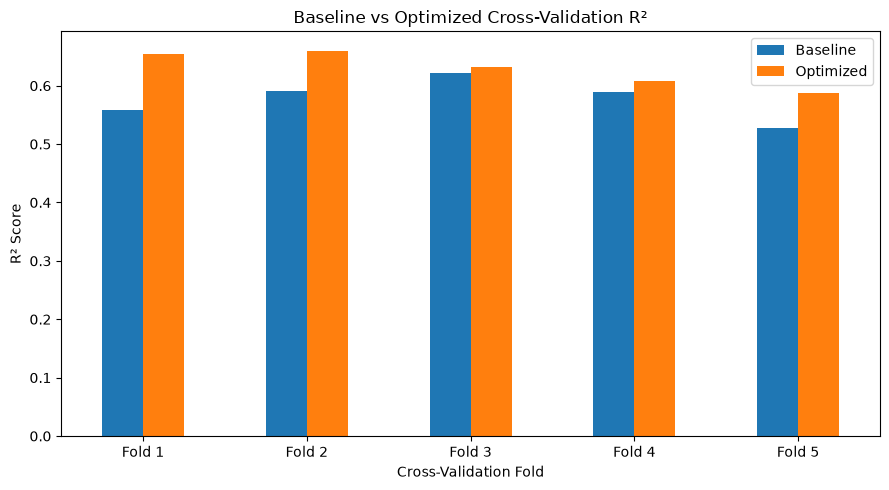

In [271]:
cv_comparison = pd.DataFrame({
    "Baseline": cv_scores,
    "Optimized": optimized_cv_scores
})

cv_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Optimized Cross-Validation R²")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")
plt.xticks(
    ticks=range(5),
    labels=["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    rotation=0
)
plt.legend()
plt.tight_layout()
plt.show()

# 29. Hyperparameter Optimization Findings

Grid Search with five-fold cross-validation was used to evaluate 243
different Gradient Boosting hyperparameter combinations.

The best configuration achieved a mean cross-validation R² of 0.6285.

### Best Hyperparameters

- `n_estimators`: 100
- `learning_rate`: 0.05
- `max_depth`: 3
- `min_samples_split`: 2
- `min_samples_leaf`: 4

The selected configuration uses a moderate learning rate and shallow
regression trees, which helps control model complexity while maintaining
predictive performance.

The best configuration improved the mean cross-validation R² from 0.5776
for the original baseline to 0.6285 after optimization.

The optimized model achieved a test-set R² of 0.6203 and an RMSE of
1,385,340.94.

MAE changed only slightly compared with the feature-selected model,
increasing from 989,665.31 to 990,544.27. Therefore, the primary benefits
of hyperparameter optimization were improved R² and RMSE rather than a
reduction in MAE.

# 30. Model Performance Comparison

The following comparison summarizes the progression of the housing price
prediction model throughout the Week 6 optimization process.

Three stages are compared:

1. Baseline Gradient Boosting
2. Feature-Selected Gradient Boosting
3. Hyperparameter-Optimized Gradient Boosting

This allows the effect of feature selection and hyperparameter tuning to be
evaluated separately.

In [272]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Feature-Selected Gradient Boosting",
        "Optimized Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        selected_mae,
        optimized_mae
    ],
    "RMSE": [
        baseline_rmse,
        selected_rmse,
        optimized_rmse
    ],
    "R²": [
        baseline_r2,
        selected_r2,
        optimized_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R²
0,Baseline Gradient Boosting,1.021294e+06,1.448481e+06,0.584911
1,Feature-Selected Gradient Boosting,9.896653e+05,1.415364e+06,0.603675
2,Optimized Gradient Boosting,9.905443e+05,1.385341e+06,0.620310


In [273]:
overall_mae_improvement = (
    (baseline_mae - optimized_mae) / baseline_mae
) * 100

overall_rmse_improvement = (
    (baseline_rmse - optimized_rmse) / baseline_rmse
) * 100

overall_r2_improvement = (
    (optimized_r2 - baseline_r2) / baseline_r2
) * 100

print("Overall Improvement: Baseline → Optimized")
print("-" * 50)
print(f"MAE improvement:  {overall_mae_improvement:.2f}%")
print(f"RMSE improvement: {overall_rmse_improvement:.2f}%")
print(f"R² improvement:   {overall_r2_improvement:.2f}%")

Overall Improvement: Baseline → Optimized
--------------------------------------------------
MAE improvement:  3.01%
RMSE improvement: 4.36%
R² improvement:   6.05%


# 32. Before vs After Optimization

The following visualizations compare the baseline and optimized Gradient
Boosting models.

For MAE and RMSE, lower values indicate better performance.

For R², higher values indicate better performance.

The comparison demonstrates the overall effect of feature engineering,
feature selection, and hyperparameter optimization on the model.

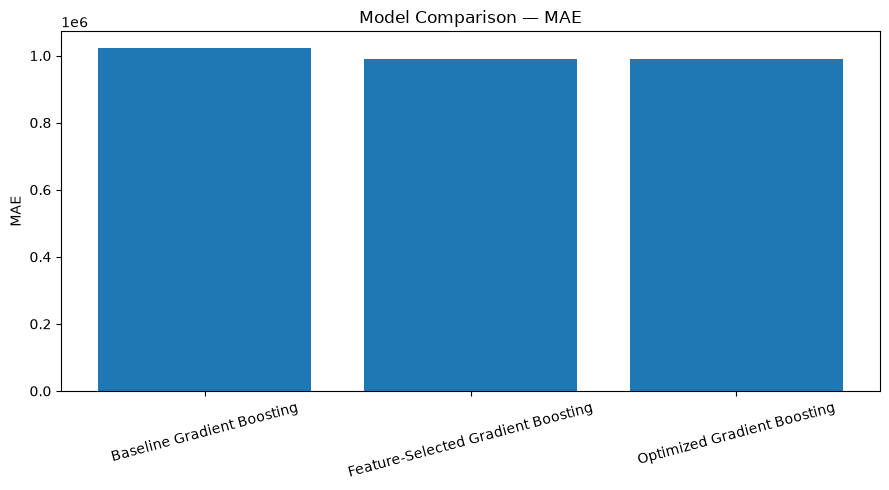

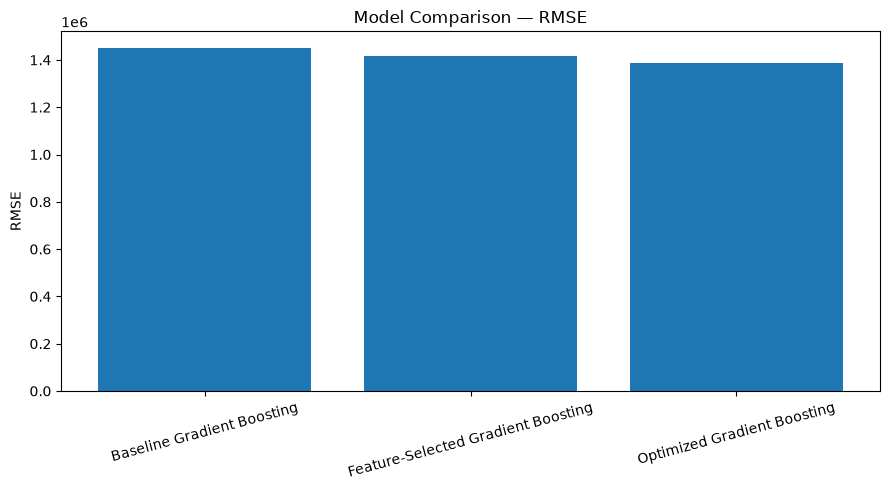

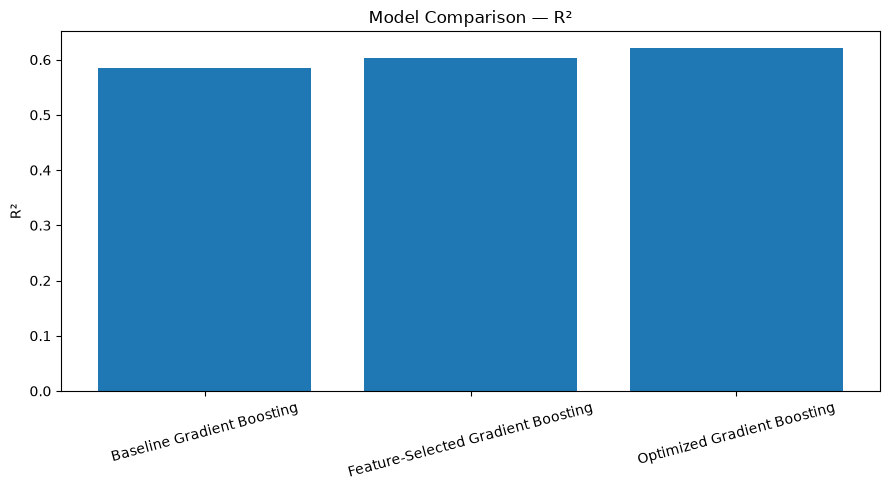

In [274]:
for metric in ["MAE", "RMSE", "R²"]:

    plt.figure(figsize=(9, 5))

    plt.bar(
        final_comparison["Model"],
        final_comparison[metric]
    )

    plt.title(f"Model Comparison — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# 33. Cross-Validation Performance

Five-fold cross-validation was used throughout the modeling process to
evaluate the consistency of the models across different subsets of the
training data.

The optimized model achieved a mean R² of 0.6285 compared with 0.5776 for
the original baseline.

Although the standard deviation increased slightly from the
feature-selected model's 0.0223 to 0.0275, it remained below the original
baseline standard deviation of 0.0324.

This indicates that the optimized model achieved substantially stronger
average validation performance while maintaining reasonable consistency
across folds.

In [275]:
cv_summary = pd.DataFrame({
    "Model": [
        "Baseline",
        "Feature-Selected",
        "Optimized"
    ],
    "Mean CV R²": [
        cv_scores.mean(),
        selected_cv_scores.mean(),
        optimized_cv_scores.mean()
    ],
    "CV Std": [
        cv_scores.std(),
        selected_cv_scores.std(),
        optimized_cv_scores.std()
    ]
})

cv_summary

,Model,Mean CV R²,CV Std
0,Baseline,0.577559,0.032435
1,Feature-Selected,0.591046,0.022291
2,Optimized,0.628488,0.027485


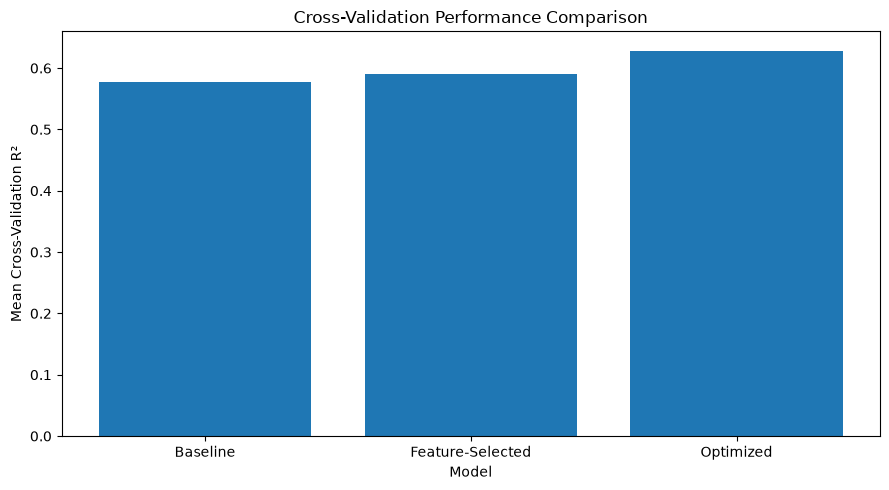

In [276]:
plt.figure(figsize=(9, 5))

plt.bar(
    cv_summary["Model"],
    cv_summary["Mean CV R²"]
)

plt.ylabel("Mean Cross-Validation R²")
plt.xlabel("Model")
plt.title("Cross-Validation Performance Comparison")
plt.tight_layout()
plt.show()

In [277]:
cv_comparison = pd.DataFrame({
    "Baseline": cv_scores,
    "Feature-Selected": selected_cv_scores,
    "Optimized": optimized_cv_scores
})

cv_comparison

,Baseline,Feature-Selected,Optimized
0,0.558274,0.570958,0.654814
1,0.590827,0.627639,0.660126
2,0.622426,0.606265,0.631987
3,0.589316,0.577050,0.607302
4,0.526955,0.573315,0.588212


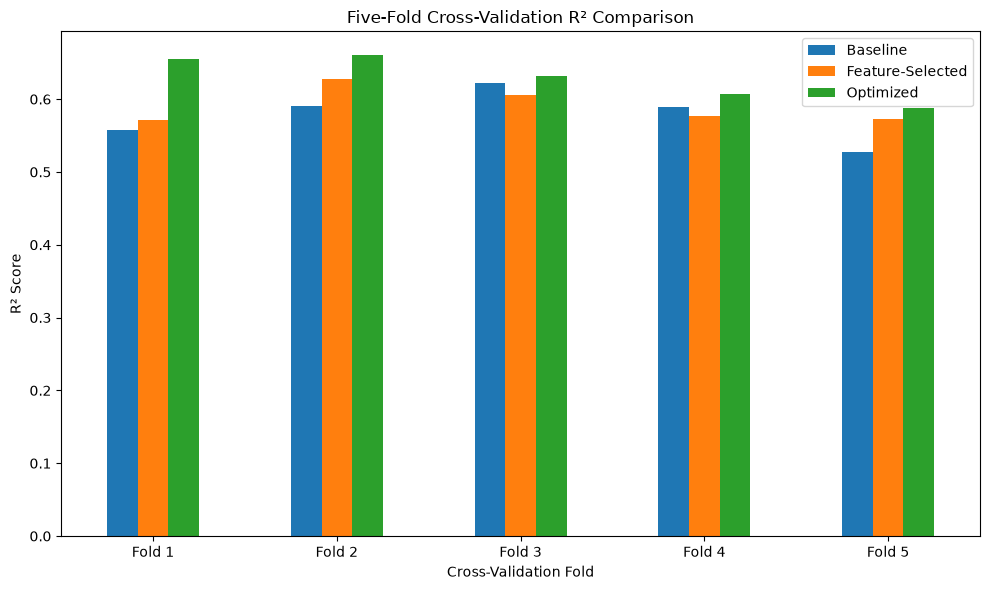

In [278]:
cv_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Five-Fold Cross-Validation R² Comparison")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")
plt.xticks(
    ticks=range(5),
    labels=[
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5"
    ],
    rotation=0
)

plt.legend()
plt.tight_layout()
plt.show()

# 35. Actual vs Predicted Prices

The actual versus predicted plot compares the prices observed in the test
dataset with the prices predicted by the optimized Gradient Boosting model.

A strong model should produce predictions that are close to the ideal
diagonal relationship between actual and predicted values.

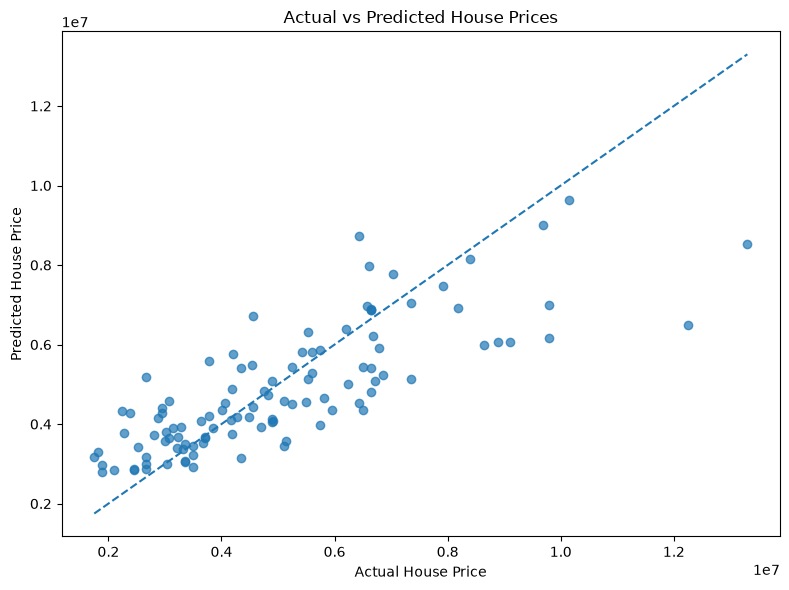

In [279]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_optimized,
    alpha=0.7
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

min_price = min(y_test.min(), y_pred_optimized.min())
max_price = max(y_test.max(), y_pred_optimized.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()

# 36. Residual Analysis

Residuals represent the difference between the actual house prices and the
prices predicted by the optimized model.

Residual analysis helps identify systematic prediction errors.

Ideally, residuals should be distributed around zero without a clear pattern.
A strong pattern may indicate that the model is failing to capture some
relationship in the data.

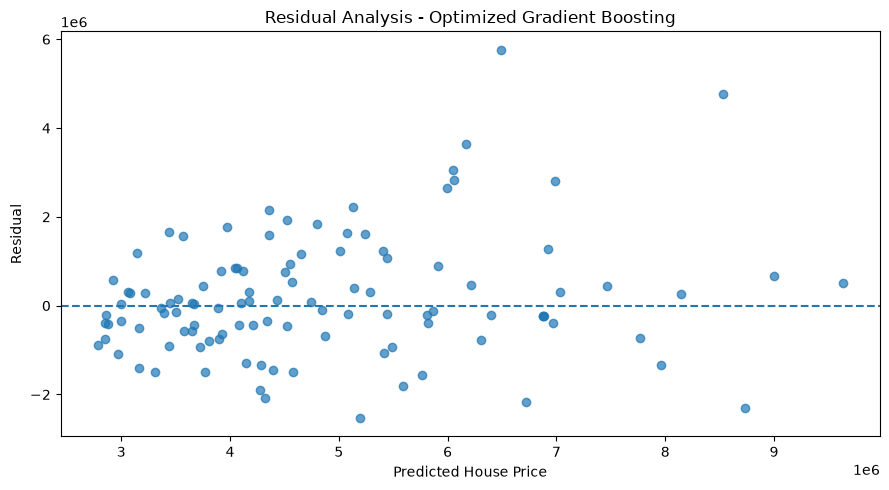

In [280]:
residuals = y_test - y_pred_optimized

plt.figure(figsize=(9, 5))

plt.scatter(
    y_pred_optimized,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Analysis - Optimized Gradient Boosting")

plt.tight_layout()
plt.show()

# 37. Final Optimized Model

The final housing price prediction model uses:

- Engineered numerical features
- One-hot encoded categorical features
- Standardized numerical variables
- Tree-based feature selection
- Gradient Boosting Regression
- Five-fold cross-validation
- Grid Search hyperparameter optimization

The final model achieved:

- **MAE:** 990,544.27
- **RMSE:** 1,385,340.94
- **R²:** 0.6203
- **Mean CV R²:** 0.6285

Compared with the Week 6 baseline, the optimized model reduced MAE by
3.01%, reduced RMSE by 4.36%, and increased R² by 6.05%.

The results demonstrate that feature selection and hyperparameter tuning
improved the overall predictive performance of the housing price model.

In [282]:
joblib.dump(
    optimized_model,
    "./../models/housing_optimized_gradient_boosting.pkl"
)

print("Optimized housing model saved successfully.")

Optimized housing model saved successfully.


# 39. Key Findings

### 1. Area was the strongest predictor

`area` was the most important feature, with a Gradient Boosting feature
importance of approximately 0.426. This indicates that property size was the
dominant predictor of house prices in the dataset.

### 2. Engineered features added useful information

Features such as `total_rooms`, `total_amenities`, `area_per_bedroom`, and
`bathrooms_per_bedroom` contributed predictive information beyond the original
variables.

### 3. Feature selection improved generalization

Feature selection reduced the transformed feature space from 24 to 12
features. Test-set R² increased from 0.5849 to 0.6037, while mean
cross-validation R² increased from 0.5776 to 0.5910.

### 4. Hyperparameter tuning further improved the model

Grid Search identified an optimal configuration with:

- 100 estimators
- 0.05 learning rate
- maximum tree depth of 3
- minimum samples split of 2
- minimum samples leaf of 4

The optimized model achieved a test R² of 0.6203 and a mean cross-validation
R² of 0.6285.

### 5. Overall optimization improved predictive performance

Compared with the original Week 6 baseline, the optimized model achieved a
3.01% reduction in MAE, a 4.36% reduction in RMSE, and a 6.05% increase in
R².

MAE changed only marginally between the feature-selected and optimized
models, indicating that the main benefit of hyperparameter tuning was
improved overall fit and reduction of larger prediction errors.